In [1]:
from flow import Flow, FlowConfig
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
%load_ext autoreload
%autoreload 2

In [2]:
config = FlowConfig()
flow = Flow(config=config)
config

FlowConfig(deterministic=False, discretize_t=True, ratio_clip=False, clip_epsilon=0.05, output_mode='u_but_supervised_as_eps', flow_vel_sacle=0.25, sde_sigma=0.0, feather_std=0.0, input_dim=1, output_dim=1, time_embed_dim=1, time_steps=10, batch_size=512, steps_per_training_steps=16)

In [3]:
optim = torch.optim.Adam(flow.parameters(), lr=1e-3)

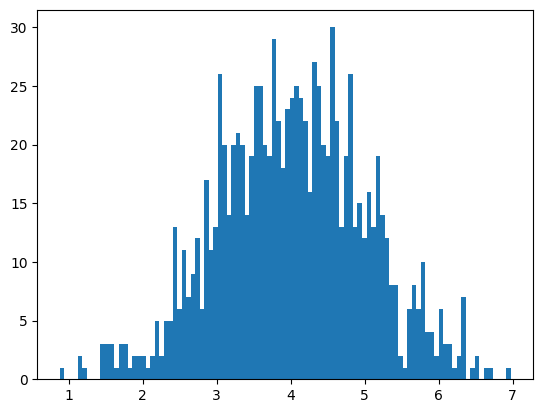

In [4]:
dest_dist = torch.distributions.Normal(4, 1)
plt.hist(dest_dist.sample((1000,)),bins=100)
plt.show()

In [5]:
epoches = 10_000
for epoch in range(epoches):
    x0 = dest_dist.sample((config.batch_size, config.input_dim))
    loss = flow.fm_training_step(x0)
    optim.zero_grad()
    loss.backward()
    optim.step()
    print(f"[Epoch: {epoch:07d}/{epoches:07d}], [Loss: {loss.item():3f}]")

[Epoch: 0000000/0010000], [Loss: 2.976258]
[Epoch: 0000001/0010000], [Loss: 1.588104]
[Epoch: 0000002/0010000], [Loss: 2.781616]
[Epoch: 0000003/0010000], [Loss: 6.243334]
[Epoch: 0000004/0010000], [Loss: 8.618862]
[Epoch: 0000005/0010000], [Loss: 6.132821]
[Epoch: 0000006/0010000], [Loss: 0.686321]
[Epoch: 0000007/0010000], [Loss: 8.204831]
[Epoch: 0000008/0010000], [Loss: 1.509330]
[Epoch: 0000009/0010000], [Loss: 5.727107]
[Epoch: 0000010/0010000], [Loss: 0.000000]
[Epoch: 0000011/0010000], [Loss: 2.712939]
[Epoch: 0000012/0010000], [Loss: 4.135607]
[Epoch: 0000013/0010000], [Loss: 15.303263]
[Epoch: 0000014/0010000], [Loss: 15.527492]
[Epoch: 0000015/0010000], [Loss: 7.648410]
[Epoch: 0000016/0010000], [Loss: 10.026843]
[Epoch: 0000017/0010000], [Loss: 7.461284]
[Epoch: 0000018/0010000], [Loss: 15.721244]
[Epoch: 0000019/0010000], [Loss: 2.636330]
[Epoch: 0000020/0010000], [Loss: 0.173041]
[Epoch: 0000021/0010000], [Loss: 1.447189]
[Epoch: 0000022/0010000], [Loss: 0.641555]
[Epoch:

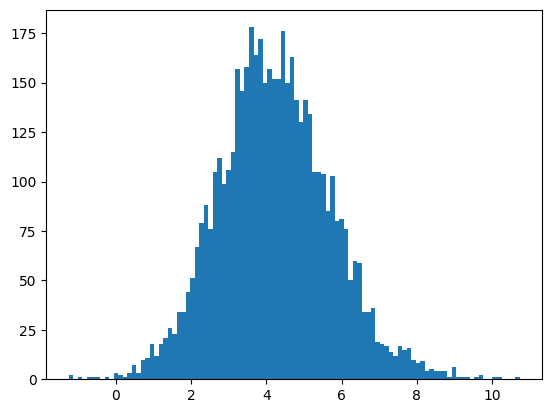

In [6]:
data, _ = flow.sample_actions(sample_num=5000)
plt.hist(data.flatten(), bins=100)
plt.show()

In [7]:
@dataclass
class RewardModel:
    mu: float
    sigma: float

    def __call__(self, x):
        return torch.exp(-(x - self.mu)**2 / (2 * self.sigma * self.sigma))

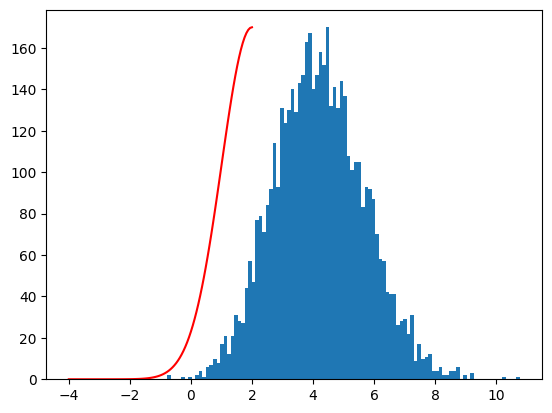

In [8]:
reward_model = RewardModel(2, 1)
x = torch.linspace(-4, 2, 100)
plt.plot(x, reward_model(x) * 170, c='r')
data, _ = flow.sample_actions(sample_num=5000)
plt.hist(data.flatten(), bins=100)
plt.show()

[Epoch:  000/0050], [Loss: -0.008]


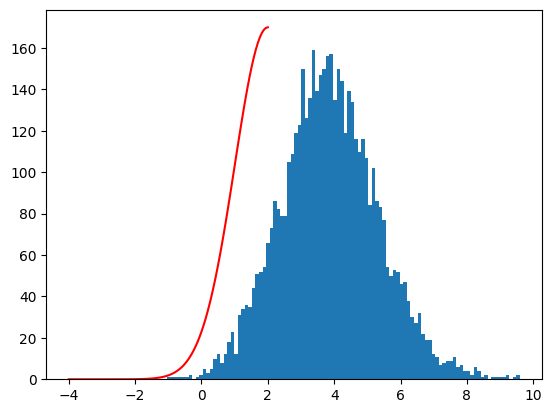

[Epoch:  001/0050], [Loss: -0.016]


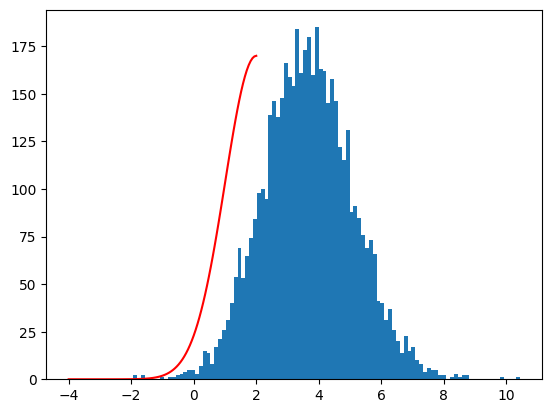

[Epoch:  002/0050], [Loss: -0.038]


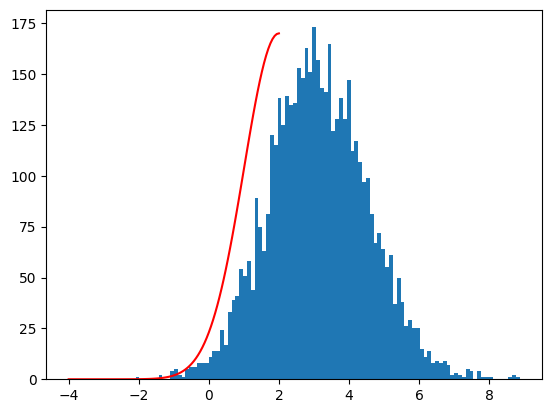

[Epoch:  003/0050], [Loss: -0.005]


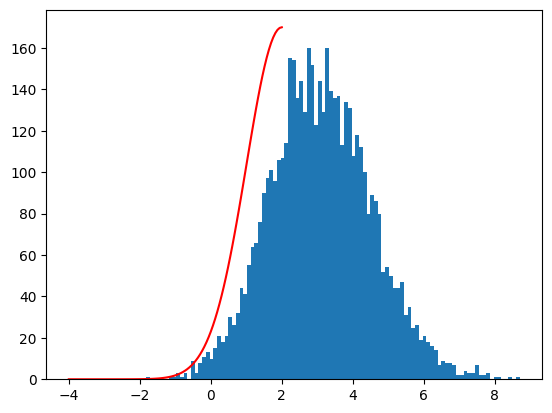

[Epoch:  004/0050], [Loss: -0.000]


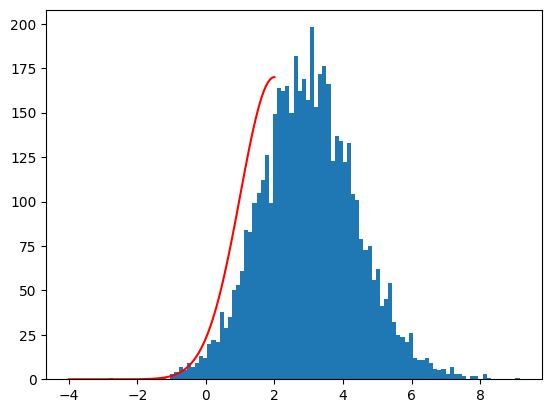

[Epoch:  005/0050], [Loss: -0.002]


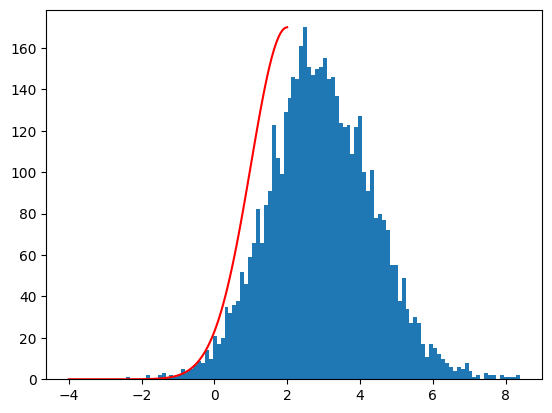

[Epoch:  006/0050], [Loss: -0.011]


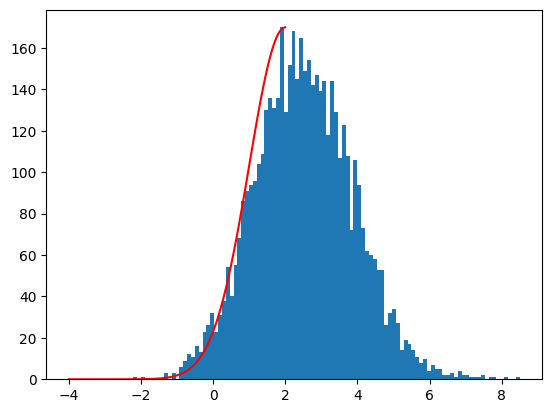

[Epoch:  007/0050], [Loss: -0.026]


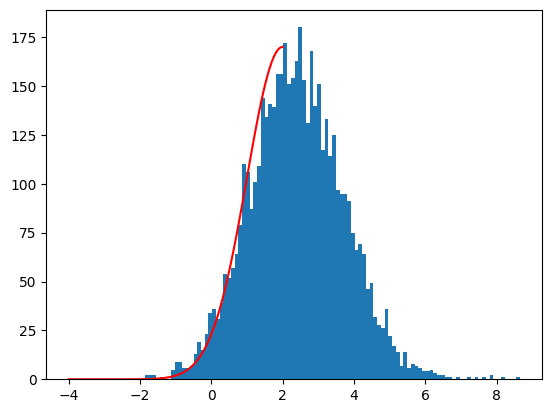

[Epoch:  008/0050], [Loss: -0.027]


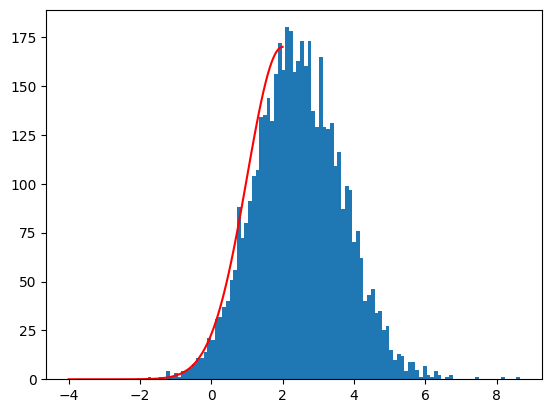

[Epoch:  009/0050], [Loss: -0.003]


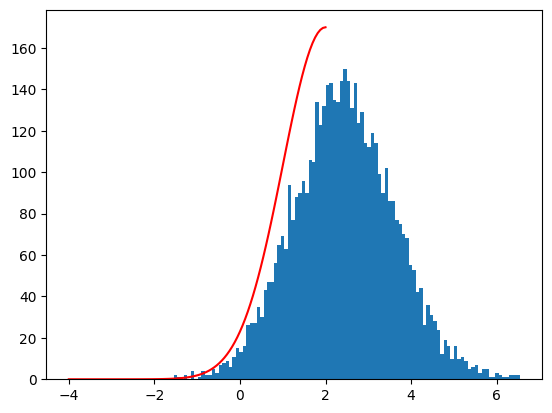

[Epoch:  010/0050], [Loss: -0.007]


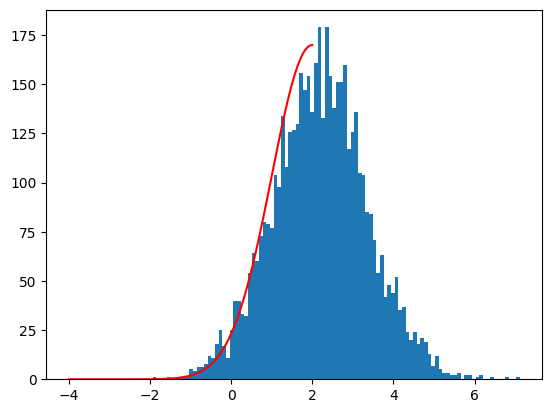

[Epoch:  011/0050], [Loss: -0.031]


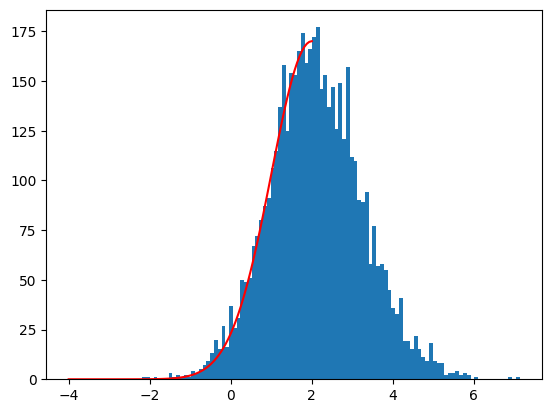

[Epoch:  012/0050], [Loss: -0.016]


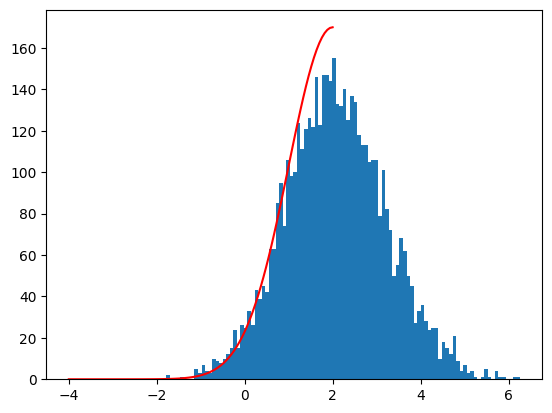

[Epoch:  013/0050], [Loss: -0.019]


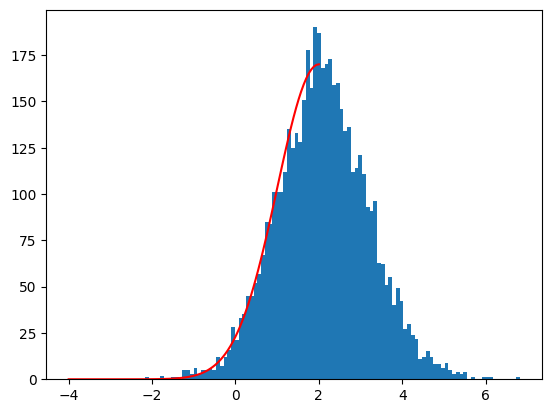

[Epoch:  014/0050], [Loss: -0.003]


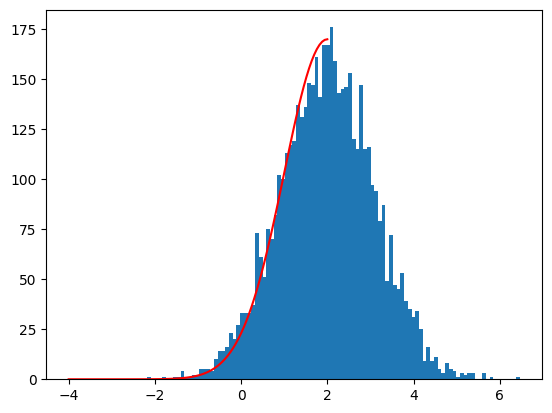

[Epoch:  015/0050], [Loss: -0.022]


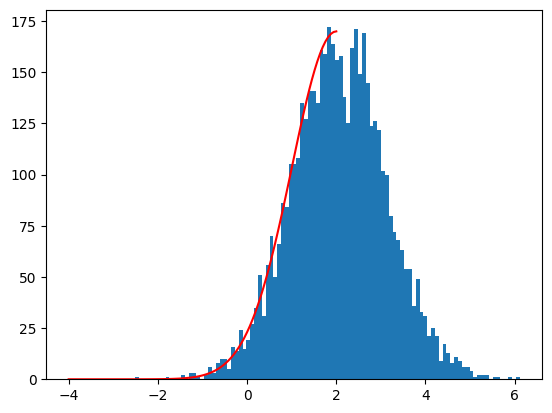

[Epoch:  016/0050], [Loss: -0.014]


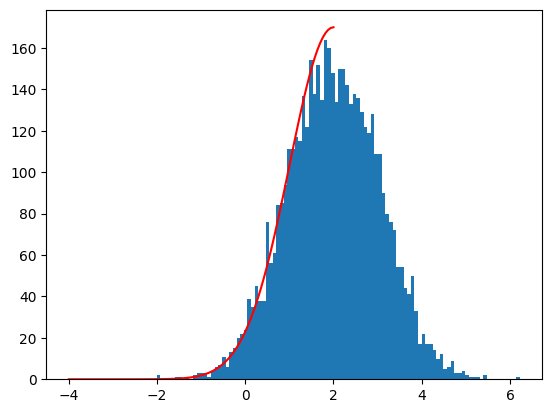

[Epoch:  017/0050], [Loss: -0.024]


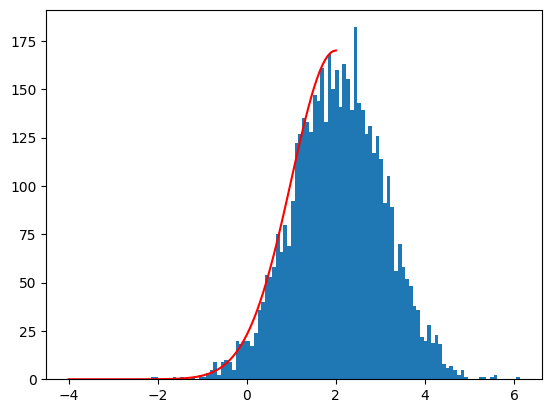

[Epoch:  018/0050], [Loss: -0.022]


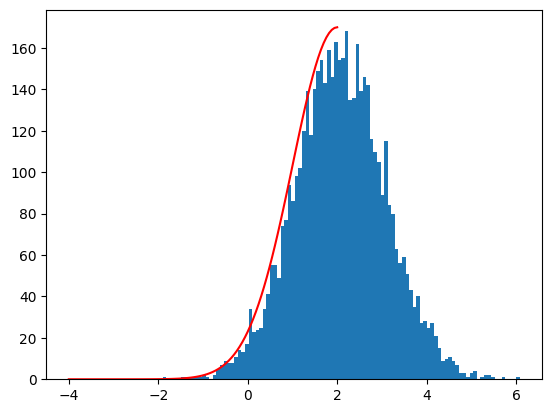

[Epoch:  019/0050], [Loss: 0.000]


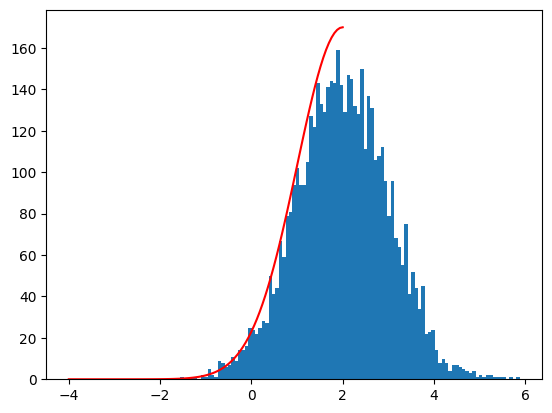

[Epoch:  020/0050], [Loss: -0.000]


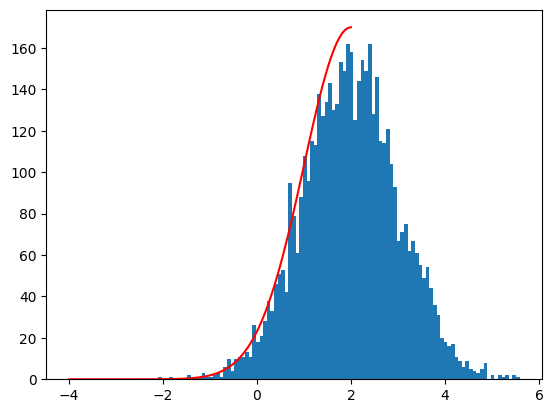

[Epoch:  021/0050], [Loss: -0.007]


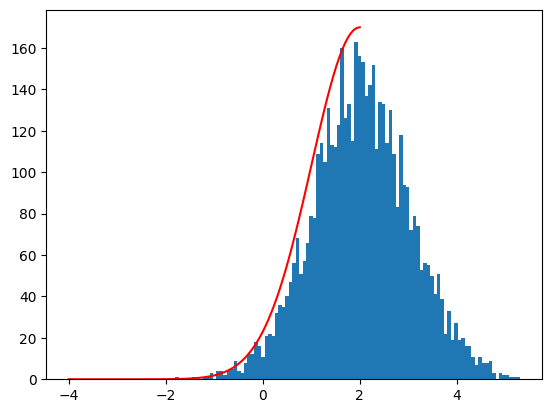

[Epoch:  022/0050], [Loss: -0.023]


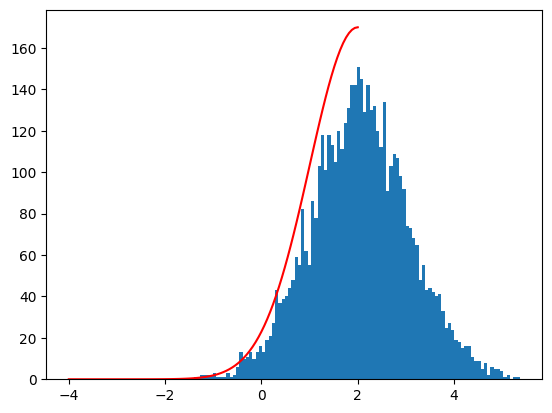

[Epoch:  023/0050], [Loss: -0.022]


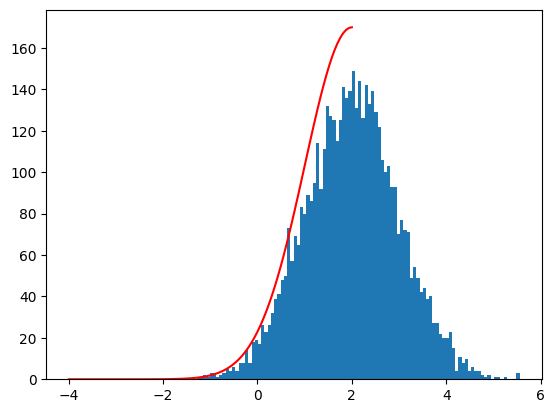

[Epoch:  024/0050], [Loss: -0.018]


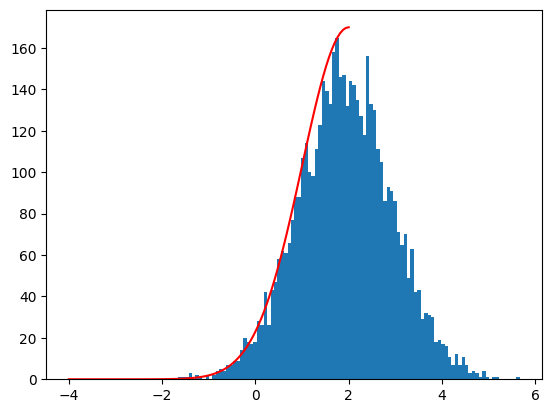

[Epoch:  025/0050], [Loss: -0.005]


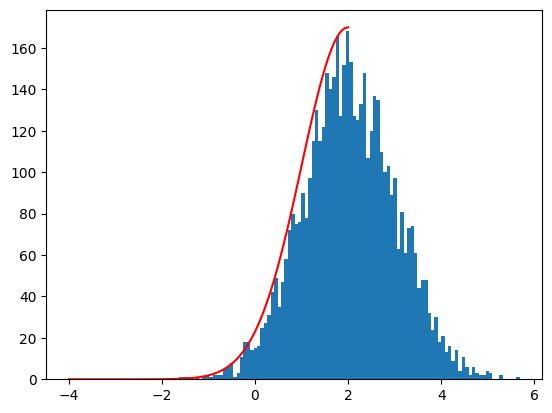

[Epoch:  026/0050], [Loss: 0.001]


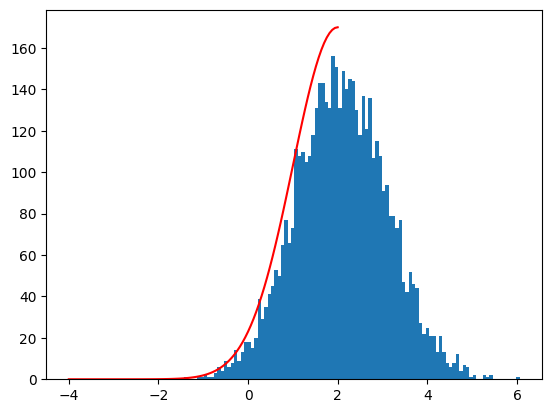

[Epoch:  027/0050], [Loss: 0.015]


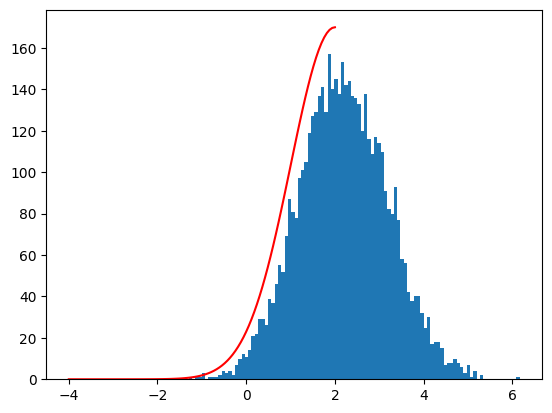

[Epoch:  028/0050], [Loss: -0.024]


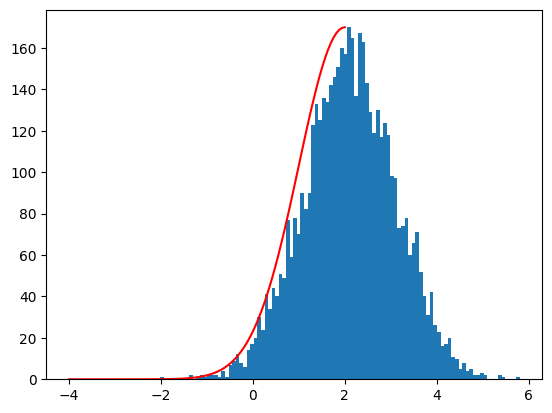

[Epoch:  029/0050], [Loss: 0.025]


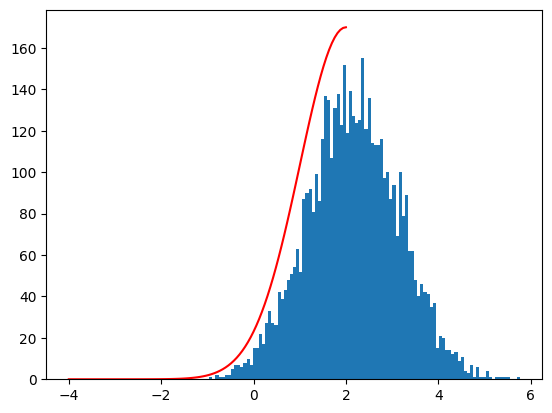

[Epoch:  030/0050], [Loss: -0.012]


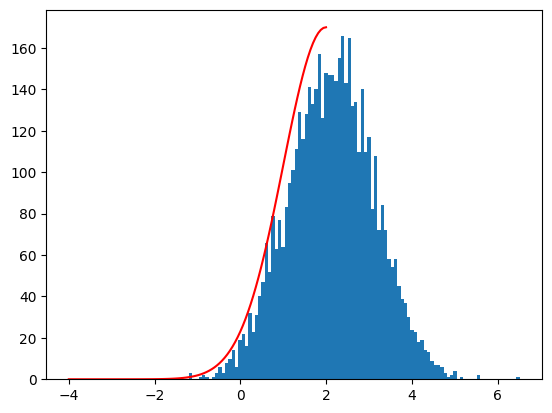

[Epoch:  031/0050], [Loss: -0.005]


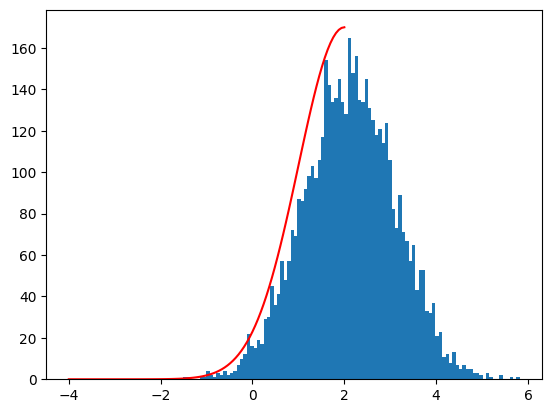

[Epoch:  032/0050], [Loss: -0.004]


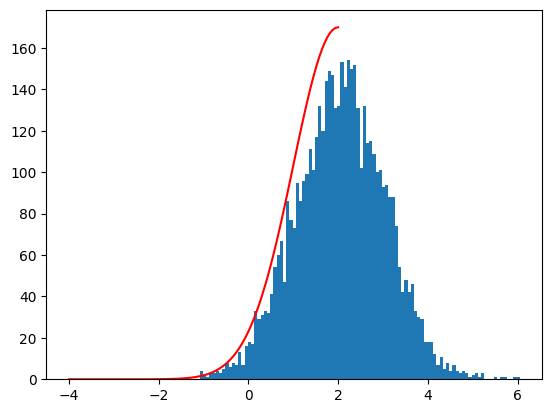

[Epoch:  033/0050], [Loss: 0.031]


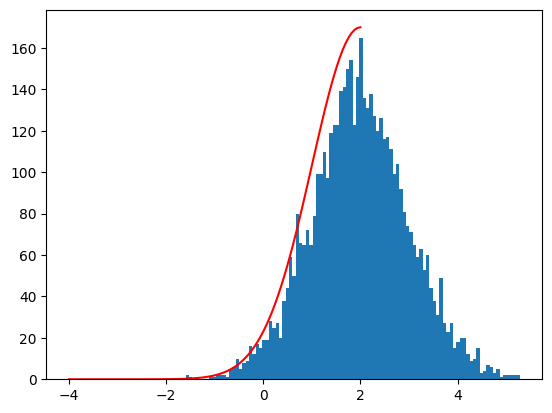

[Epoch:  034/0050], [Loss: -0.012]


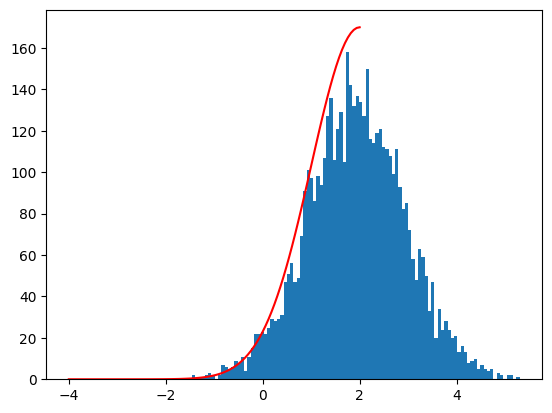

[Epoch:  035/0050], [Loss: 0.007]


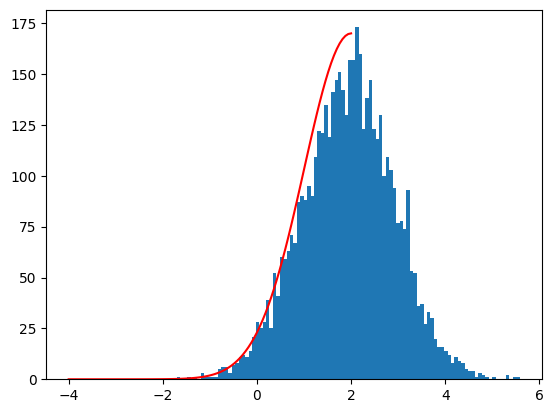

[Epoch:  036/0050], [Loss: 0.006]


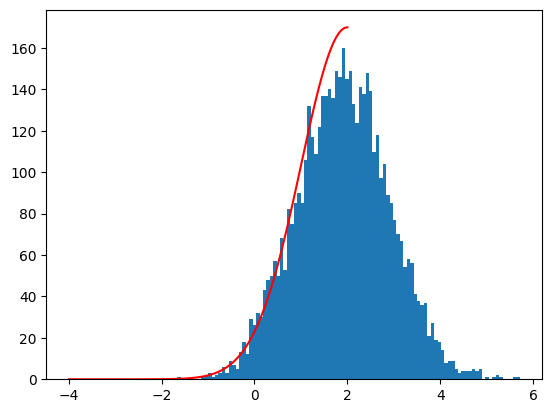

[Epoch:  037/0050], [Loss: 0.004]


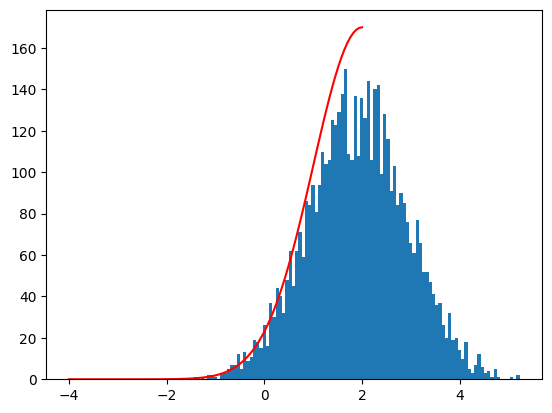

[Epoch:  038/0050], [Loss: -0.000]


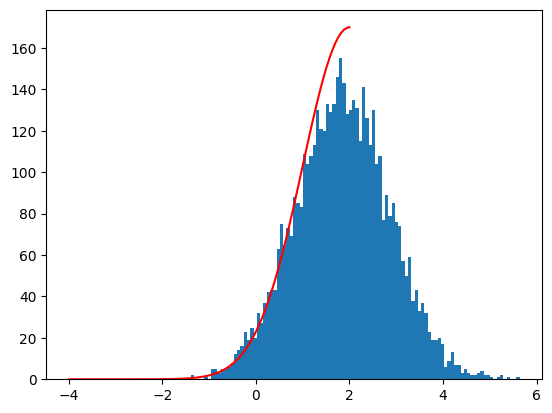

[Epoch:  039/0050], [Loss: 0.011]


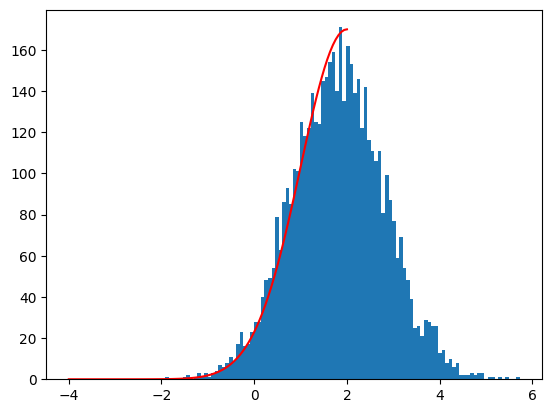

[Epoch:  040/0050], [Loss: -0.006]


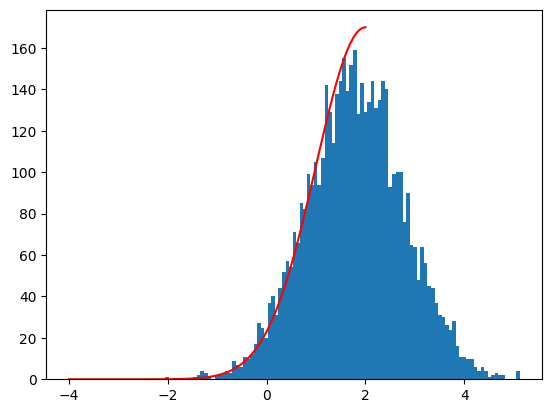

[Epoch:  041/0050], [Loss: 0.016]


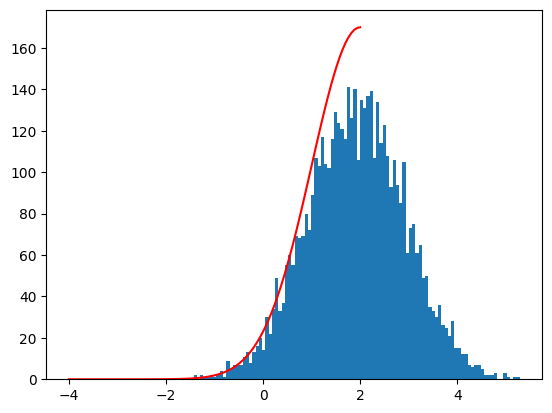

[Epoch:  042/0050], [Loss: 0.011]


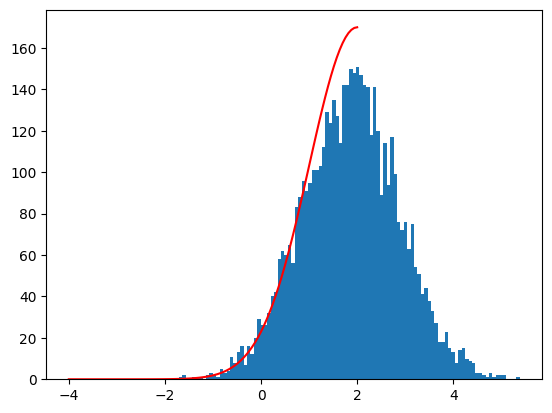

[Epoch:  043/0050], [Loss: 0.056]


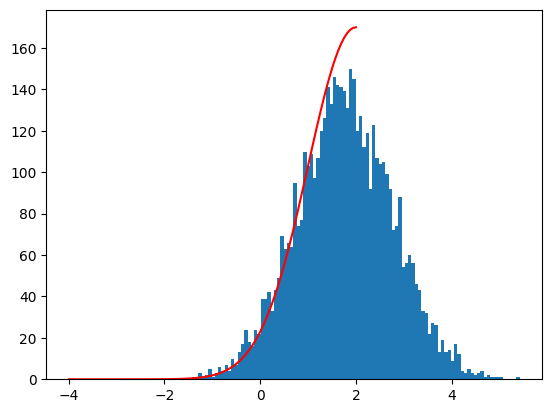

[Epoch:  044/0050], [Loss: 0.047]


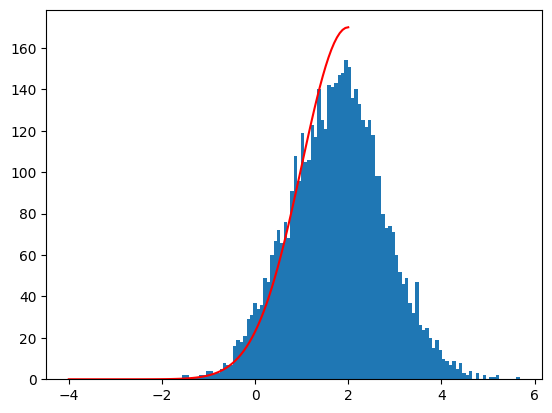

[Epoch:  045/0050], [Loss: 0.041]


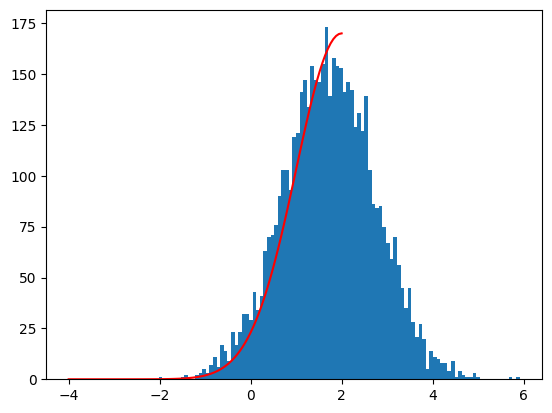

[Epoch:  046/0050], [Loss: 0.037]


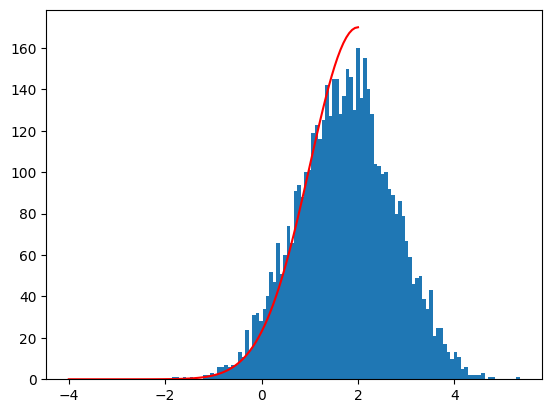

[Epoch:  047/0050], [Loss: 0.087]


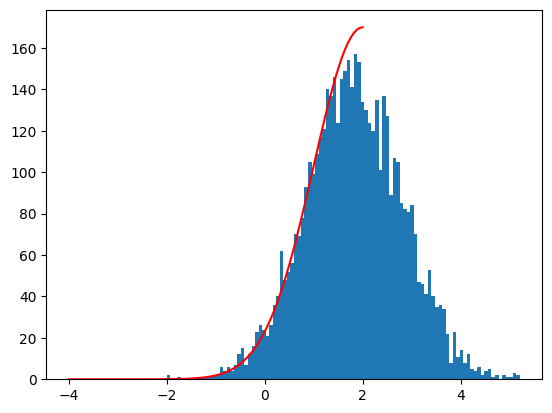

[Epoch:  048/0050], [Loss: -0.008]


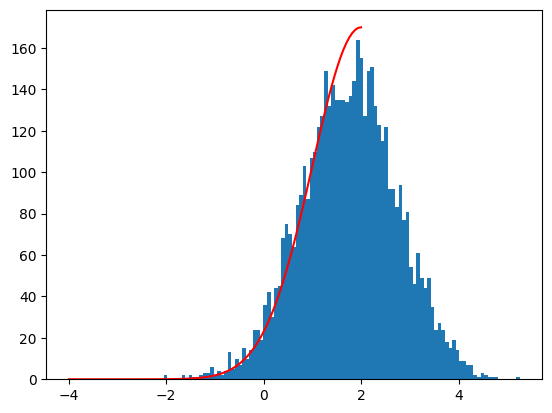

[Epoch:  049/0050], [Loss: 0.002]


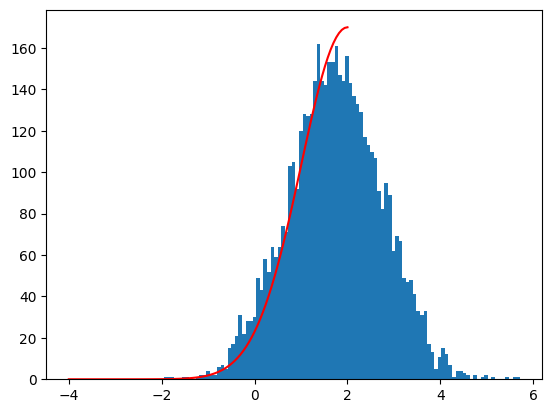

In [ ]:
rl_epoches = 50
for epoch in range(rl_epoches):
    _, bags = flow.sample_actions()
    last_loss: float = flow.rl_training_step(bags, reward_model, optim)
    print(f"[Epoch: {epoch: 04d}/{rl_epoches:04d}], [Loss: {last_loss:.3f}]")

    x = torch.linspace(-4, 2, 100)
    plt.plot(x, reward_model(x) * 170, c='r')
    data, _ = flow.sample_actions(sample_num=5000)
    plt.hist(data.flatten(), bins=100)
    plt.show()